In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [4]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


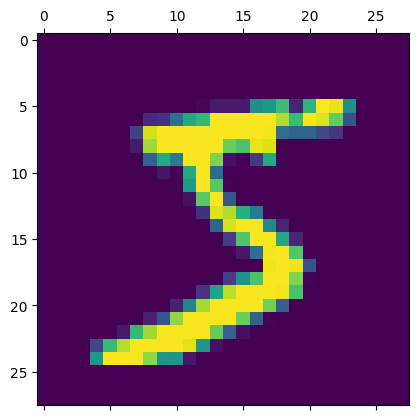

In [5]:
plt.matshow(X_train[0])

In [6]:
y_train[0]

np.uint8(5)

In [8]:
X_train = X_train / 255
X_test = X_test / 255

In [9]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [15]:

cnn_model = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

X_train_reshaped = X_train.reshape(-1, 28, 28, 1)
X_test_reshaped = X_test.reshape(-1, 28, 28, 1)

model_fit = cnn_model.fit(X_train_reshaped, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.6363 - loss: 1.0590 - val_accuracy: 0.8912 - val_loss: 0.3575
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9069 - loss: 0.3151 - val_accuracy: 0.9340 - val_loss: 0.2298
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9329 - loss: 0.2215 - val_accuracy: 0.9433 - val_loss: 0.1897
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.9475 - loss: 0.1754 - val_accuracy: 0.9567 - val_loss: 0.1480
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.9549 - loss: 0.1501 - val_accuracy: 0.9614 - val_loss: 0.1325


In [16]:
cnn_model.evaluate(X_test_reshaped, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9636 - loss: 0.1226


[0.12263719737529755, 0.9635999798774719]

In [17]:
y_pred = cnn_model.predict(X_test_reshaped)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [18]:
y_pred_labels = [np.argmax(i) for i in y_pred]

In [19]:
y_pred_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [20]:
import numpy as np
predicted = np.argmax(y_pred[0])

In [21]:
predicted

np.int64(7)

In [23]:
y_pred[0]

array([6.8959829e-09, 3.6553628e-11, 3.9116653e-06, 9.6476570e-06,
       5.0551203e-13, 6.3753369e-08, 7.9467731e-16, 9.9998206e-01,
       4.8459925e-09, 4.1668300e-06], dtype=float32)

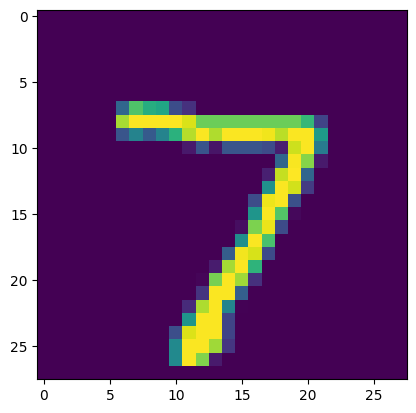

In [24]:
plt.imshow(X_test[0].reshape(28,28))
plt.show()

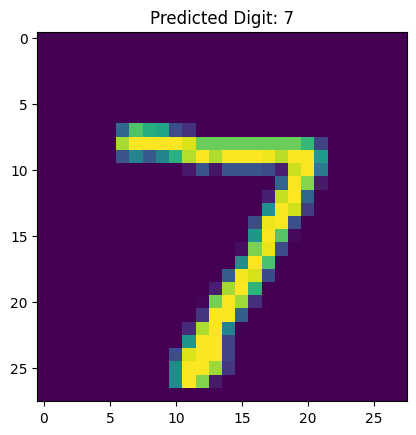

In [25]:
plt.imshow(X_test[0].reshape(28,28))

plt.title(f"Predicted Digit: {y_pred_labels[0]}")

plt.show()

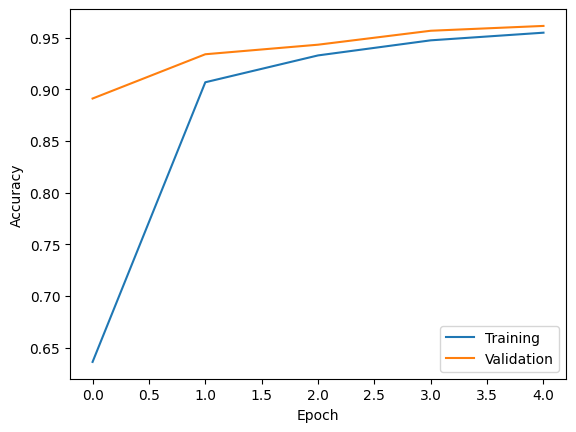

In [26]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training', 'Validation'])

plt.show()

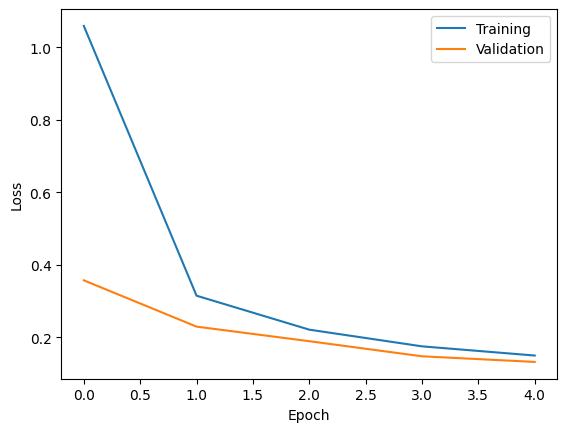

In [27]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training', 'Validation'])

plt.show()

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_labels)
cm

array([[ 969,    0,    1,    0,    1,    0,    5,    1,    3,    0],
       [   0, 1120,    3,    1,    0,    0,    4,    0,    7,    0],
       [   2,    2, 1003,    4,    2,    0,    0,   12,    6,    1],
       [   0,    0,   18,  959,    0,    7,    0,    9,   15,    2],
       [   1,    2,    3,    0,  946,    0,    5,    5,    3,   17],
       [  10,    0,    1,   19,    0,  831,   10,    2,   14,    5],
       [   6,    3,    1,    0,    4,    3,  938,    0,    3,    0],
       [   2,    2,   26,    5,    3,    1,    0,  979,    3,    7],
       [   7,    0,    9,    9,    3,    0,    1,    5,  937,    3],
       [  11,    6,    3,    6,   10,    3,    0,   13,    3,  954]])

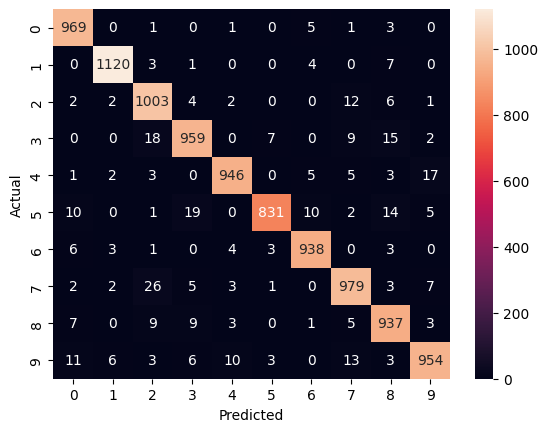

In [29]:
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()